# Statistical Arbitrage: Pairs Trading on Consumer Staples

**Author:** Ayaan Khalid

---

## Overview

This project implements a **statistical arbitrage (stat arb) pairs trading strategy** on US consumer staples stocks, based on the framework established by Gatev, Goetzmann & Rouwenhorst (2006) which is one of the most cited academic papers on pairs trading.

### What is Pairs Trading?
Pairs trading is a **market-neutral strategy**. Instead of betting on whether the market goes up or down, it bets on the *relationship* between two stocks. The idea is:
- Find two stocks that historically move together (cointegrated)
- When they diverge from their normal relationship, bet that they will converge back
- Short the relatively expensive stock, long the relatively cheap one
- Profit when the spread reverts to its mean

Because you are simultaneously long and short, the strategy has low directional market exposure as it is designed to generate **consistent, low-volatility returns** rather than high absolute returns.

### Why Consumer Staples?
Consumer staples companies share stable, long-term demand drivers. Household spending on food, beverages, and personal care products does not change dramatically with economic cycles. This makes cointegration more likely and more persistent than in growth sectors.

---

## Key Concepts

### Cointegration (Engle-Granger, 1987)
Two stocks are cointegrated if their prices move together in the long run even if they drift apart in the short term. It is stronger than correlation. Correlation measures whether two stocks move in the same direction, but cointegration means their *spread* always reverts to a stable mean. We test for this using the **Engle-Granger cointegration test**, which returns a p-value. A p-value below 0.05 (5% significance level, following Gatev et al. 2006) means the pair is statistically cointegrated.

### Hedge Ratio (OLS Regression)
The spread is not simply `s1 - s2` as the two stocks trade at different price levels. We use **Ordinary Least Squares (OLS) regression** to estimate a hedge ratio `β` such that:

```
spread = s1 - β × s2
```

This scales the second stock appropriately so the spread fluctuates around a stable mean.

### Stationarity (Augmented Dickey-Fuller Test)
A time series is stationary if its mean and variance do not change over time. Raw stock prices are almost never stationary since they trend upward. But the *spread* between two cointegrated stocks should be stationary. We verify this using the **Augmented Dickey-Fuller (ADF) test**. A p-value below 0.05 confirms stationarity.

### Z-Score
Measures how many standard deviations the current spread is from its historical mean:
```
z = (spread - mean) / std
```
- **Z > +2:** spread too wide --> short s1, long s2
- **Z < -2:** spread too narrow --> long s1, short s2  
- **|Z| < 0.5:** spread reverted --> exit trade

### Mean Reversion
The core assumption is that the spread between two cointegrated stocks will always return to its historical average. This is the opposite of momentum; instead of betting trends continue, we bet that deviations correct.

## 1. Imports & Setup

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

plt.style.use('seaborn-darkgrid')
plt.rcParams['figure.dpi'] = 120

## 2. Universe: Consumer Staples

We select 11 well-known consumer staples stocks spanning beverages, fast food, retail, household care, and packaged food. Stocks within the same sector share common demand drivers, making cointegration more likely and more persistent.

In [2]:
consumer = ['KO', 'PEP', 'MCD', 'YUM', 'WMT', 'COST', 'PG', 'CL', 'KHC', 'GIS', 'CPB']

#download data
prices = yf.download(consumer, start="2019-01-01", end="2026-06-01", auto_adjust=True)["Close"]
prices = prices.ffill().dropna()

print(f"Shape: {prices.shape}")
print(prices.head())

[*********************100%***********************]  11 of 11 completed

Shape: (1862, 11)
Ticker             CL        COST        CPB        GIS        KHC         KO  \
Date                                                                            
2019-01-02  49.558578  184.861771  24.670401  29.119268  29.806618  37.341606   
2019-01-03  49.324387  180.943573  24.976294  29.573904  29.785999  37.110859   
2019-01-04  49.784431  186.197952  25.113945  30.172499  30.597534  37.850845   
2019-01-07  50.085537  186.884109  25.763973  30.672588  31.175232  37.357506   
2019-01-08  50.645947  188.283478  25.957161  31.134806  31.202738  37.779236   

Ticker             MCD        PEP         PG        WMT        YUM  
Date                                                                
2019-01-02  147.795395  86.693657  75.348259  27.913778  79.630608  
2019-01-03  146.821594  85.884491  74.819954  27.770235  77.627640  
2019-01-04  149.659012  87.645653  76.347061  27.943687  79.648003  
2019-01-07  151.287537  86.891998  76.041634  28.272642  79.560921  


## 3. Cointegration Testing

We test every possible pair in the universe using the **Engle-Granger cointegration test** at the 5% significance level (following Gatev et al. 2006). Pairs with a p-value below 0.05 are statistically cointegrated as there is less than a 5% chance the result is a false positive.

In [3]:
def find_cointegrated_pairs(price_data, significance=0.05):
    tickers = price_data.columns.tolist()
    pairs = []
    for t1, t2 in combinations(tickers, 2):
        s1 = price_data[t1].dropna()
        s2 = price_data[t2].dropna()
        s1, s2 = s1.align(s2, join='inner')
        _, pvalue, _ = coint(s1, s2)
        if pvalue < significance:
            pairs.append((t1, t2, round(pvalue, 4)))
    return pd.DataFrame(pairs, columns=['Stock 1', 'Stock 2', 'P-Value'])

pairs_df = find_cointegrated_pairs(prices)
print("=== Cointegrated Consumer Staples Pairs ===")
print(pairs_df.sort_values('P-Value'))

=== Cointegrated Consumer Staples Pairs ===
  Stock 1 Stock 2  P-Value
1     GIS     KHC   0.0054
0      CL    COST   0.0119
2     MCD     YUM   0.0169


## 4. Stationarity Verification: ADF Test & Hedge Ratio

Passing the cointegration test is necessary but not sufficient. We also verify that the hedge ratio-adjusted spread is **stationary** using the Augmented Dickey-Fuller (ADF) test.

The naive spread `s1 - s2` fails because the two stocks trade at different price levels. Instead we use **OLS regression** to estimate a hedge ratio `β` that properly scales the relationship:

```
s1 = α + β × s2 + ε
spread = s1 - β × s2
```

The residual `ε` (the spread) should be stationary if the pair is genuinely cointegrated.

In [4]:
def compute_spread(s1, s2):
    X = add_constant(s2)
    model = OLS(s1, X).fit()
    hedge_ratio = model.params.iloc[1]
    spread = s1 - hedge_ratio * s2
    return spread, hedge_ratio

def check_stationarity(s1, s2, name):
    spread, hedge_ratio = compute_spread(s1, s2)
    adf_result = adfuller(spread)
    stationary = adf_result[1] < 0.05
    print(f"{name}: hedge ratio = {round(hedge_ratio, 4)}, ADF p-value = {round(adf_result[1], 4)} - {'Stationary' if stationary else 'Not stationary'}")

check_stationarity(prices['GIS'], prices['KHC'], 'GIS/KHC')
check_stationarity(prices['CL'], prices['COST'], 'CL/COST')
check_stationarity(prices['MCD'], prices['YUM'], 'MCD/YUM')

GIS/KHC: hedge ratio = 1.8114, ADF p-value = 0.001 - Stationary
CL/COST: hedge ratio = 0.0373, ADF p-value = 0.0025 - Stationary
MCD/YUM: hedge ratio = 2.0696, ADF p-value = 0.0038 - Stationary


All three pairs are cointegrated at the 5% level and their hedge ratio-adjusted spreads are stationary. These pass both tests and are valid pairs to trade.

## 5. Backtester

We implement an event-driven backtester that iterates through each trading day and reacts to z-score signals:

- **Entry threshold: ±2.0** --> enter when spread is 2 standard deviations from mean
- **Exit threshold: 0.5** --> exit when spread reverts to within 0.5 standard deviations of mean
- **Capital: $10,000** split equally between the two legs
- Each pair is backtested independently with the same starting capital

In [5]:
def backtest_pair(s1, s2, hedge_ratio, entry_threshold=2.0, exit_threshold=0.5, capital=10000):
    spread = s1 - hedge_ratio * s2
    spread_mean = spread.mean()
    spread_std = spread.std()
    zscore = (spread - spread_mean) / spread_std

    position = 0
    portfolio_value = []
    shares_s1 = 0
    shares_s2 = 0
    cash = capital

    for i in range(len(zscore)):
        z = zscore.iloc[i]
        p1 = s1.iloc[i]
        p2 = s2.iloc[i]

        #short spread: z too high --> s1 expensive relative to s2
        if z > entry_threshold and position == 0:
            shares_s2 = (capital / 2) / p2    #long s2
            shares_s1 = -(capital / 2) / p1   #short s1
            position = -1

        #long spread: z too low --> s1 cheap relative to s2
        elif z < -entry_threshold and position == 0:
            shares_s1 = (capital / 2) / p1    #long s1
            shares_s2 = -(capital / 2) / p2   #short s2
            position = 1

        #exit: spread has reverted
        elif abs(z) < exit_threshold and position != 0:
            cash = capital + shares_s1 * p1 + shares_s2 * p2
            shares_s1 = 0
            shares_s2 = 0
            position = 0

        total = cash + shares_s1 * p1 + shares_s2 * p2
        portfolio_value.append(total)

    return pd.Series(portfolio_value, index=s1.index)

#get hedge ratios
_, hr_gis_khc = compute_spread(prices['GIS'], prices['KHC'])
_, hr_cl_cost = compute_spread(prices['CL'], prices['COST'])
_, hr_mcd_yum = compute_spread(prices['MCD'], prices['YUM'])

#run backtests
port_gis_khc = backtest_pair(prices['GIS'], prices['KHC'], hr_gis_khc)
port_cl_cost = backtest_pair(prices['CL'], prices['COST'], hr_cl_cost)
port_mcd_yum = backtest_pair(prices['MCD'], prices['YUM'], hr_mcd_yum)

print("GIS/KHC final value:", round(port_gis_khc.iloc[-1], 2))
print("CL/COST final value:", round(port_cl_cost.iloc[-1], 2))
print("MCD/YUM final value:", round(port_mcd_yum.iloc[-1], 2))

GIS/KHC final value: 10536.51
CL/COST final value: 10763.93
MCD/YUM final value: 10591.3


## 6. Benchmarks

We use two benchmarks appropriate for a market-neutral strategy:

- **3-Month T-Bill (^IRX):** The standard benchmark for market-neutral strategies. Since pairs trading aims to be uncorrelated with the market, the relevant question is whether it beats the risk-free rate and not the equity market.
- **XLP (Consumer Staples Select Sector SPDR Fund):** A passive ETF tracking the exact sector we are trading in. If pairs trading cannot beat simply holding the sector ETF, it does not justify the added complexity.

In [6]:
#T-Bill
tbill = yf.download("^IRX", start="2019-01-01", end="2026-06-01", auto_adjust=True)["Close"]
tbill_daily = (tbill / 100) / 252
tbill_cumulative = (1 + tbill_daily).cumprod() * 10000
tbill_cumulative = tbill_cumulative.reindex(port_cl_cost.index, method='ffill')
tbill_final = float(tbill_cumulative.iloc[-1])

#XLP
xlp = yf.download("XLP", start="2019-01-01", end="2026-06-01", auto_adjust=True)["Close"]
xlp_cumulative = 10000 * (xlp / xlp.iloc[0])
xlp_cumulative = xlp_cumulative.reindex(port_cl_cost.index, method='ffill')
xlp_final = float(xlp_cumulative.iloc[-1])

print(f"T-Bill final value: ${tbill_final:,.2f}")
print(f"XLP final value: ${xlp_final:,.2f}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

T-Bill final value: $12,193.36
XLP final value: $19,898.05


## 7. Performance Metrics

We compare all strategies on four key metrics. Note: Sharpe ratio is excluded for T-Bills as the near-zero daily variance of the rate series produces a meaningless result.


| Metric | Description |
|--------|-------------|
| **Final Value** | Portfolio value at end of period |
| **Total PnL** | Profit or loss in dollars |
| **Sharpe Ratio** | Return per unit of risk (annualised) |
| **Max Drawdown** | Worst peak-to-trough decline |

In [7]:
def compute_metrics(series, capital=10000):
    returns = series.pct_change().dropna()
    final = float(series.iloc[-1])
    pnl = final - capital
    sharpe = float(returns.mean() / returns.std() * np.sqrt(252))
    rolling_max = series.cummax()
    max_dd = float(((series - rolling_max) / rolling_max).min())
    return final, pnl, sharpe, max_dd

gis_final, gis_pnl, gis_sharpe, gis_dd = compute_metrics(port_gis_khc)
cl_final, cl_pnl, cl_sharpe, cl_dd = compute_metrics(port_cl_cost)
mcd_final, mcd_pnl, mcd_sharpe, mcd_dd = compute_metrics(port_mcd_yum)
xlp_final_m, xlp_pnl, xlp_sharpe, xlp_dd = compute_metrics(xlp_cumulative)

print(f"{'Metric':<20} {'GIS/KHC':>10} {'CL/COST':>10} {'MCD/YUM':>10} {'T-Bill':>10} {'XLP':>10}")
print("-" * 72)
print(f"{'Final Value':<20} ${gis_final:>9,.0f} ${cl_final:>9,.0f} ${mcd_final:>9,.0f} ${tbill_final:>9,.0f} ${xlp_final:>9,.0f}")
print(f"{'Total PnL':<20} ${gis_pnl:>9,.0f} ${cl_pnl:>9,.0f} ${mcd_pnl:>9,.0f} ${tbill_final-10000:>9,.0f} ${xlp_pnl:>9,.0f}")
print(f"{'Sharpe Ratio':<20} {gis_sharpe:>10.2f} {cl_sharpe:>10.2f} {mcd_sharpe:>10.2f} {'N/A':>10} {xlp_sharpe:>10.2f}")
print(f"{'Max Drawdown':<20} {gis_dd:>10.2%} {cl_dd:>10.2%} {mcd_dd:>10.2%} {'~0%':>10} {xlp_dd:>10.2%}")

Metric                  GIS/KHC    CL/COST    MCD/YUM     T-Bill        XLP
------------------------------------------------------------------------
Final Value          $   10,537 $   10,764 $   10,591 $   12,193 $   19,898
Total PnL            $      537 $      764 $      591 $    2,193 $    9,898
Sharpe Ratio               0.12       0.25       0.19        N/A       0.67
Max Drawdown            -26.84%     -7.30%     -8.63%        ~0%    -24.51%


## 8. Visualisation

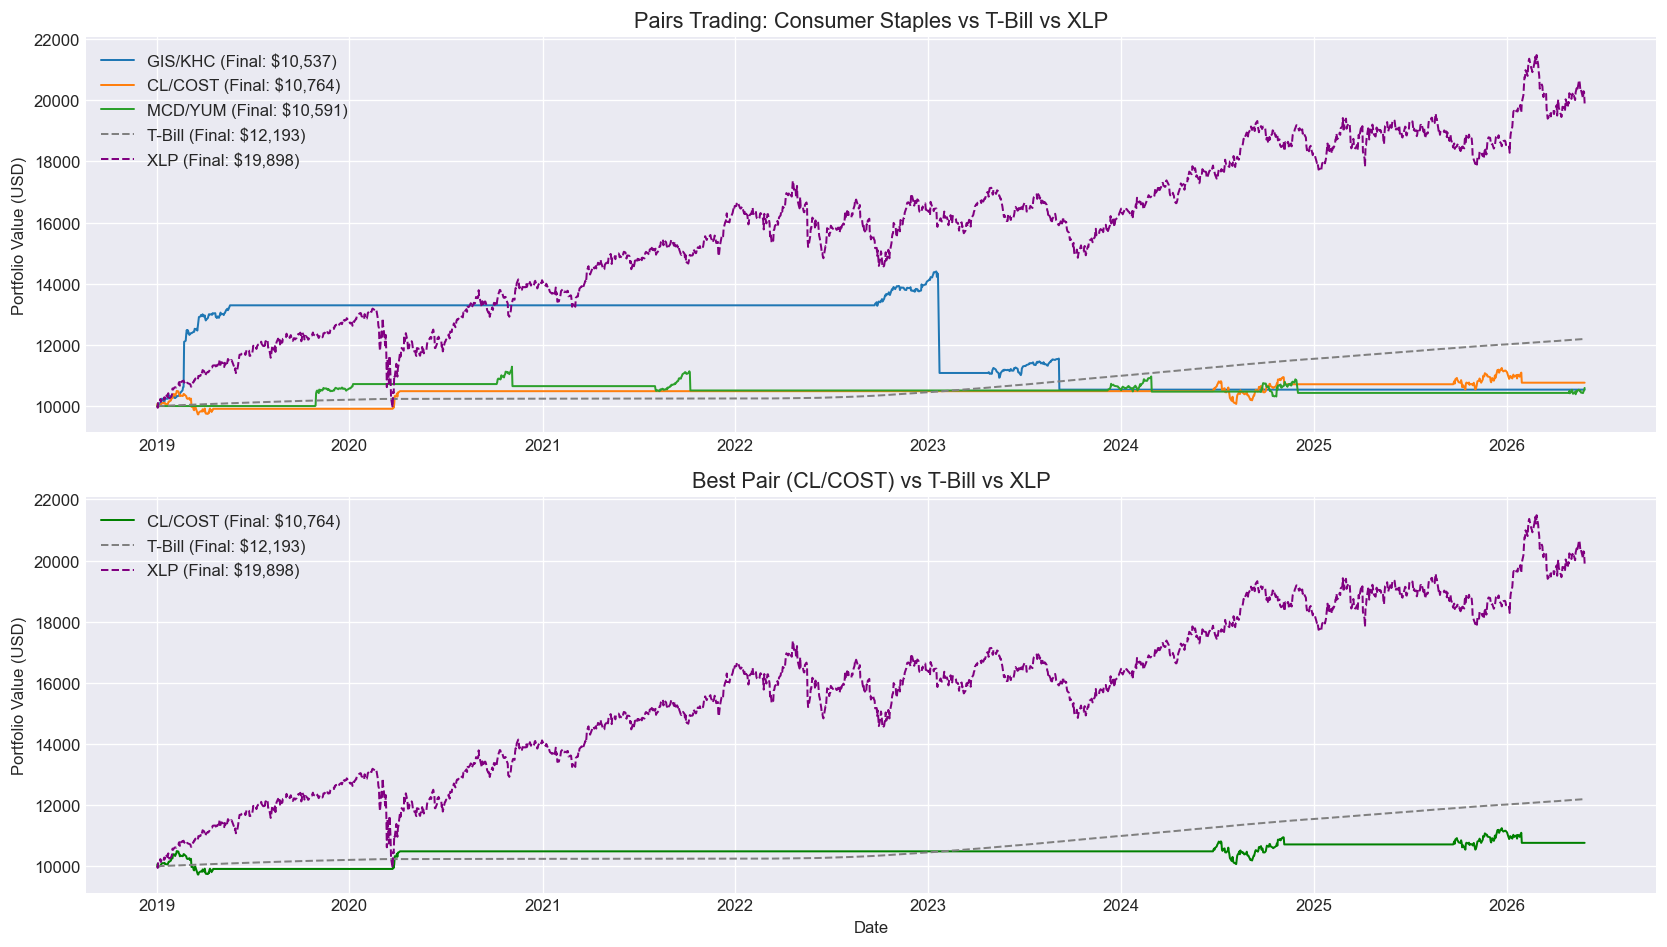

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

#top: all pairs + benchmarks
axes[0].plot(port_gis_khc, label=f"GIS/KHC (Final: ${gis_final:,.0f})", linewidth=1.2)
axes[0].plot(port_cl_cost, label=f"CL/COST (Final: ${cl_final:,.0f})", linewidth=1.2)
axes[0].plot(port_mcd_yum, label=f"MCD/YUM (Final: ${mcd_final:,.0f})", linewidth=1.2)
axes[0].plot(tbill_cumulative, label=f"T-Bill (Final: ${tbill_final:,.0f})",
             linewidth=1.2, linestyle='--', color='grey')
axes[0].plot(xlp_cumulative, label=f"XLP (Final: ${xlp_final:,.0f})",
             linewidth=1.2, linestyle='--', color='purple')
axes[0].set_title("Pairs Trading: Consumer Staples vs T-Bill vs XLP", fontsize=13)
axes[0].set_ylabel("Portfolio Value (USD)")
axes[0].legend()

#bottom: best pair vs benchmarks
axes[1].plot(port_cl_cost, color="green", label=f"CL/COST (Final: ${cl_final:,.0f})", linewidth=1.2)
axes[1].plot(tbill_cumulative, color="grey", label=f"T-Bill (Final: ${tbill_final:,.0f})",
             linewidth=1.2, linestyle='--')
axes[1].plot(xlp_cumulative, color="purple", label=f"XLP (Final: ${xlp_final:,.0f})",
             linewidth=1.2, linestyle='--')
axes[1].set_title("Best Pair (CL/COST) vs T-Bill vs XLP", fontsize=13)
axes[1].set_ylabel("Portfolio Value (USD)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Case Study: GIS/KHC - Notable Drawdowns

The GIS/KHC portfolio shows two notable crashes worth examining. This kind of event-driven analysis illustrates the real-world risks of pairs trading.

### Early 2023 Crash (approximately  `$14,500 to $11,000`)
GIS reached an all-time high of ~$90 in May 2023 before sharply declining. The divergence from KHC was driven by:
- **Consumer shift to private labels:** Post-pandemic inflation pushed shoppers toward cheaper store-brand alternatives, hurting GIS volumes more than KHC
- **Price increases backfiring:** GIS implemented aggressive price hikes that depressed demand. Reuters noted early signs of consumer price sensitivity by late 2023
- **Repeated guidance cuts:** GIS cut its full-year earnings outlook multiple times through 2023-2024

Meanwhile KHC held up relatively better due to stronger presence in emerging markets and better cost control. The spread widened dramatically as our strategy was positioned expecting convergence but GIS continued falling, generating sustained losses.

### Later 2023 Minor Crash
A secondary drop occurred when GIS reported weaker than expected quarterly results in late 2023; organic revenue missed estimates, retailer inventory reductions hurt the topline, and full-year EPS guidance came in below expectations. The stock fell ~5.9% in a single session.

### Key Takeaway
These crashes illustrate the core risk of pairs trading as **cointegration can break down**. GIS and KHC were statistically cointegrated over the full period, but company-specific fundamental divergence caused extended periods where the spread did not revert as expected. A more robust implementation would include **stop losses** to exit positions when the spread moves beyond a certain threshold, rather than holding indefinitely and absorbing further losses.

## 10. Conclusion

### Results Summary
All three consumer staples pairs generated modest positive returns (`$537-$764`), but **underperformed both benchmarks**, the T-Bill (`$2,193`) and XLP (`$9,898`). The simple pairs trading implementation does not add value over passive alternatives in this period.

However, the strategy's **max drawdown profile is compelling**. CL/COST and MCD/YUM experienced maximum drawdowns of only -7.3% and -8.6% respectively, far lower than XLP's drawdown. This confirms the market-neutral property: pairs trading does protect capital during downturns, even when it fails to generate competitive returns.

### Why did pairs trading underperform?
1. **High rate environment (2022–2024):** The Federal Reserve's aggressive rate hike cycle pushed T-Bill yields to 5%+, making the risk-free rate unusually high. Simple pairs trading strategies historically thrived in low-rate environments where the opportunity cost of sitting flat was low.
2. **Static hedge ratio:** The hedge ratio was computed over the full backtest period, implicitly using future information. A rolling hedge ratio recomputed on a trailing window would be more realistic and likely more robust.
3. **No stop losses:** When cointegration broke down (as with GIS/KHC in 2023), the strategy held losing positions indefinitely rather than cutting losses at a predefined threshold.
4. **Cointegration instability:** As demonstrated by the GIS/KHC case study, statistical relationships between stocks can break down due to company-specific fundamental shifts such as private label competition, earnings misses, sector rotation which the model does not account for.

### Limitations
- **Static hedge ratio:** Computed over the full period using future data. A proper implementation would use a rolling OLS window.
- **No stop losses:** Extended losing positions when cointegration breaks down rather than exiting at a loss threshold.
- **No transaction costs:** Each entry and exit incurs real brokerage costs and bid-ask spread, which would further reduce already modest returns.
- **Small universe:** Only 11 tickers tested. A larger universe increases the probability of finding genuinely cointegrated pairs.
- **Short selling assumptions:** Real short selling involves borrow costs, margin requirements, and short-squeeze risk, none of which are modelled here.